# Multiplexed Uniform State Preparation

$$
\renewcommand{\ket}[1]{|#1\rangle}
\renewcommand{\bra}[1]{\langle#1|}
$$

In the [USP tutorial](Uniform_State_Preparation.ipynb), we saw that given an integer, $d$, we can create a uniform superposition over $d$ basis states using Hadamards and amplitude amplification. In some cases, we may have a set of integer values $\{d_i\}_{i=0}^{D-1}$ that have been loaded coherently to the quantum computer, for example, via a QROM. In this case, we can use multiplexing to prepare a superposition of uniform superposition states such that the number of states in each corresponds to a value from this set:

$$ \frac{1}{\sqrt{D}} \sum_{i=0}^{D-1} \ket{i}_{index} \ket{d_i}_{data} \left( \sum_{j=0}^{d_i-1} \frac{1}{\sqrt{d_i}} \ket{j}_{target} \right)$$

This  _multiplexed USP_ subroutine is presented in "Even more efficient quantum computations of chemistry through tensor hypercontraction" ([arxiv:2011.03494](https://arxiv.org/abs/2011.03494)). See step 3.(a) of the double factorization compilation in Appendix C.

In this tutorial, we will go over the two implementations of multiplexed USP offered by Workbench Algorithms:
[`MultiplexedUSP`](https://construct.psiquantum.com/docs/psiqdk-algorithms/autoapi/psiqdk/algorithms/index.html#psiqdk.algorithms.MultiplexedUSP) and [`MultiplexedRealUSP`](https://construct.psiquantum.com/docs/psiqdk-algorithms/autoapi/psiqdk/algorithms/index.html#psiqdk.algorithms.MultiplexedRealUSP).
Both Qubricks use a `Contiguizer` subroutine which we will go over first.

In [1]:
from psiqdk.workbench import QPU, Qubits, Qubrick

from psiqdk.algorithms import (
    Contiguizer,
    MultiplexedRealUSP,
    MultiplexedUSP,
    SelectNaive,
    USP,
)

## The Contiguizer

The first step of uniform state preparation is to perform Hadamard gates on the subset of 'active' qubits that the state will be loaded onto. 

 > For example, if you wanted to load 6 uniform amplitudes, you would need to perform a Hadamard gate on 3 qubits.

When performing USP in superposition over multiple values, the number of Hadamards needed will be different, so you need to be careful about how many are performed for any given branch of the iterations. 

The solution is to use a _contiguized_ register, that is, to create a new register and fill it with `1`s up to the bit length of a given number.
> For example, in binary 6 is `110`, so the bit length is 3 and the contiguized register would load `111`.

Since this can be done in superposition, this new register can then be used to perform a series of controlled Hadamards.

In Workbench Algorithms, we have the [`Contiguizer`](https://construct.psiquantum.com/docs/psiqdk-algorithms/autoapi/psiqdk/algorithms/index.html#psiqdk.algorithms.Contiguizer) Qubrick that performs this operation. 

The `compute` takes in a target register (`target_reg`, type Qubits) and optionally a control (`ctrl`, type Qubits). 
During the compute it will assign a result register of equal size to the target register which can be accessed via `get_result_qreg`.

The circuit and its output are shown below:

|target_reg|copy_reg>
|0|0>    0.353553+0.000000j
|1|1>    0.353553+0.000000j
|2|3>    0.353553+0.000000j
|3|3>    0.353553+0.000000j
|4|7>    0.353553+0.000000j
|5|7>    0.353553+0.000000j
|6|7>    0.353553+0.000000j
|7|7>    0.353553+0.000000j


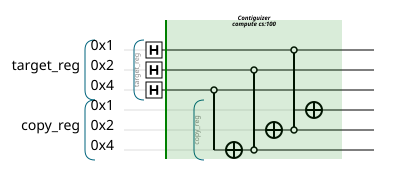

In [2]:
num_qubits = 3 
qpu = QPU(num_qubits=2 * num_qubits)
target_reg = Qubits(num_qubits, "target_reg", qpu)

# Create equal superposition on target register
target_reg.had()

# Call Contiguizer on target register
contiguizer_qbk = Contiguizer()
contiguizer_qbk.compute(target_reg=target_reg)

qpu.print_state_vector()
qpu.draw(show_qubricks=True)

<!-- We can see from the state vector that when the target register hold $x$, the copy register will hold $2^{bitlength(x)}-1.$  -->

We can see from the state vector that for each basis state in the target register, $\ket{b}$, the copy register will contain the state $\ket{2^{bitlength(b)}-1}.$ 

## MultiplexedUSP

The `MultiplexedUSP` Qubrick can be initialized with a contiguizer (which defaults to `Contiguizer`) and a multiplexor Qubrick (which defaults to `ZeroAncMultiplexor`).

The `compute` now takes:
- the target register to load the uniform states onto (`psi`, type Qubits),
- the register containing a superposition of indices to multiplex over (`index_reg`, type Qubits),
- the register containing a superposition of the values of $d$ which dictate the size of uniform state preparation to perform (`data_reg`, type Qubits),
- a list of these values of $d$ (`data`, List(int)),
- an optional control qubit (`ctrl`, type Qubits).

Let's see an example! We first will set up the index and data registers required. Then we just need to call the `MultiplexedUSP` Qubrick on these along with the target register and the list of $\{d\}$:

In [3]:
# Helper qubrick to set up the index and data register
class CreateIndexedSuperpositionOverD(Qubrick):
    def _compute(self, index_register, d_register, d_list):
         # Create a uniform superposition of size corresponding to the number of d's 
        USP().compute(len(d_list), index_register)
        # Given one basis in the superposition, load one value from the list of d's
        SelectNaive().compute(index_register, d_register, d_list)

|index_register|data_register|target_register|?>
|0|2|0|.>    -0.353553+0.353553j
|0|2|1|.>    -0.353553+0.353553j
|1|3|0|.>    -0.235702+0.333333j
|1|3|1|.>    -0.235702+0.333333j
|1|3|2|.>    -0.235702+0.333333j


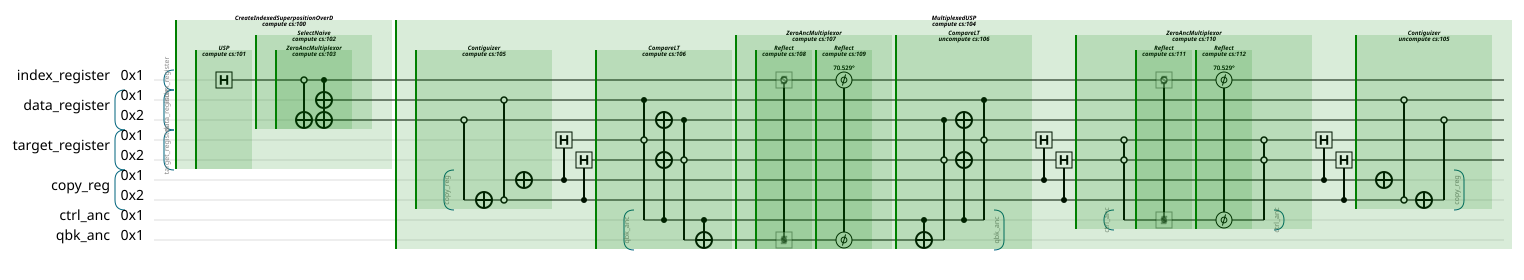

In [4]:
# The values of d we will multiplex over
d_list = [2, 3]

# Set up QPU and registers
qpu = QPU(num_qubits=9)
index_register = Qubits(1, "index_register", qpu)
data_register = Qubits(2, "data_register", qpu)
target_register = Qubits(2, "target_register", qpu)

# Precompute -- load superposition of relevant d
CreateIndexedSuperpositionOverD().compute(index_register, data_register, d_list)

# Instantiate the multiplexed USP instance with a multiplexor 
musp = MultiplexedUSP()
# Call compute on registers and list of d values 
musp.compute(psi=target_register, index_reg=index_register, data_reg=data_register, data=d_list)

qpu.print_state_vector()
qpu.draw(show_qubricks=True)

What's going on in this circuit ? 

The initial USP and Select within `CreateIndexedSuperpositionOverD` are simply preparing an equally weighted superposition of the relevant $d$ values. This data is expected to be in the register before compute. In particular, `MultiplexedUSP` expects an index register and a data register that effectively performs a quantum `for` loop over the different values in $\{d\}$:

$$ \frac{1}{\sqrt{D}} \sum_{i=0}^{D-1} \ket{i}_{index} \ket{d_i}_{data} $$

Then we see the `Contiguizer` in action: based on the value of $d$ in the data register we will apply the appropriate number of Hadamards over the 'active' qubits.

Next we perform amplitude amplification. We select the states we'd like to keep via a comparator that checks for the value in the target register is less than the value in the data register. The optimal angle of the reflections is now dependent on $d$. Hence, we see a multiplexor selecting which phase gates to apply based on the value in the index register. 

The resulting state is such that for every basis state `i` of the index register, the target register is in the uniform superposition state given by the `i`th element of `data`:

$$ \frac{1}{\sqrt{D}} \sum_{i=0}^{D-1}  \ket{i}_{index} \ket{d_i}_{data} \left( \sum_{j=0}^{d_i-1} \frac{1}{\sqrt{d_i}} \ket{j}_{target} \right) $$

We can see this is true from the state vector!
When the index register is in state $\ket{0}$, the data register holds the value 2, which is the first element of $\{d\}$, and the target register is in an equal superposition of 2 basis states. 
When the index register is in state $\ket{1}$, the data register holds the value 3, which is the second element of $\{d\}$, and the target register is in an equal superposition of 3 basis states.

> As discussed in the [USP tutorial](Uniform_State_Preparation.ipynb), the state is prepared up to a global phase. If the preparation is uncontrolled, this is not problematic. If it is controlled, we will need to perform a phase fix-up (a phase gate on the control qubit) to avoid introducing local phase errors.

## MultiplexedRealUSP

The second Qubrick is `MultiplexedRealUSP`. Its initialization and compute signature is identical to `MultiplexedUSP`.

It works on the same principle of amplitude amplification using multiplexed rotations with rotation angles dependent on $d$. But, instead of using phase gates it uses one additional auxiliary qubit and Ry rotations such that the reflections can be done with CZ gates. This is exactly what is used in `RealUSP`.

Let's see an example:

|index_register|data_register|target_register|?>
|0|2|0|.>    -0.462910+0.000000j
|0|2|1|.>    -0.462910+0.000000j
|1|3|0|.>    -0.436436+0.000000j
|1|3|1|.>    -0.436436+0.000000j
|1|3|2|.>    -0.436436+0.000000j


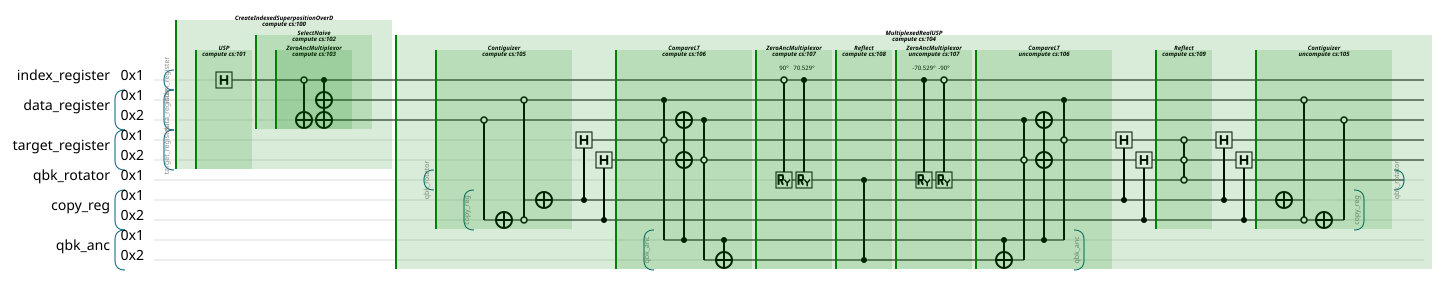

In [5]:
# The values of d we're going to multiplex over
d_list = [2, 3]

# Set up QPU and registers
qpu = QPU(num_qubits=10)
index_register = Qubits(1, "index_register", qpu)
data_register = Qubits(2, "data_register", qpu)
target_register = Qubits(2, "target_register", qpu)

# Precompute -- load superposition of relevant d
CreateIndexedSuperpositionOverD().compute(index_register, data_register, d_list)

# Compute the multiplexed USP
musp = MultiplexedRealUSP()
musp.compute(psi=target_register, index_reg=index_register, data_reg=data_register, data=d_list)

qpu.print_state_vector()
qpu.draw(show_qubricks=True)

Again we can see that when the index register is in state $\ket{0}$, the data register holds the value 2, which is the first element of $\{d\}$, and the target register is in an equal superposition of 2 basis states. When the index register is in state $\ket{1}$, the data register holds the value 3, which is the second element of $\{d\}$, and the target register is in an equal superposition of 3 basis states.

The difference is that now all the amplitudes are purely real!

> We have again introduced a global phase, but this time it's simply $-1$. When the routine is applied uncontrolled, this is not a problem. If it is controlled, we need to do a phase fix-up (a Z gate on the control qubit) to avoid introducing local phase errors.

## Resource analysis of MultiplexedUSP variants
We can compare the QREs for these two implementations. We will generate the circuit (but not simulate the state vector) for a quantum state with 100 different d values, for each of which we will create the corresponding uniform state preparation over on the target register.

In [6]:
import numpy as np 
from psiqdk.workbench.filter_presets import NO_SIM_DEFAULT
from psiqdk.workbench.qre import resource_estimator

def get_resources(usp_qbk):
    d_list = list(range(100))

    # Set up QPU and registers
    qpu = QPU(num_qubits=42, filters=NO_SIM_DEFAULT)
    index_register = Qubits(7, "index_register", qpu)
    data_register = Qubits(7, "data_register", qpu)
    target_register = Qubits(7, "target_register", qpu)
    
    # Precompute -- load superposition of relevant d
    CreateIndexedSuperpositionOverD().compute(index_register, data_register, d_list)
    
    # Compute the multiplexed USP
    usp_qbk().compute(psi=target_register, index_reg=index_register, data_reg=data_register, data=d_list)

    resources = resource_estimator(qpu).resources()
    return (resources['toffs'] + resources['gidney_lelbows'],
            resources['qubit_highwater'], 
            resources['active_volume']
           )
    
print(f"| Multiplexed USP Qubrick | Toffoli gates | Qubits | Active Volume |")
for qbk in [MultiplexedUSP, MultiplexedRealUSP]:
    resources = get_resources(usp_qbk = qbk)
    print(f"| {qbk.__name__.ljust(23)} "
          f"| {str(resources[0]).ljust(13)} "
          f"| {str(resources[1]).ljust(7)}"
          f"| {str(resources[2]).ljust(13)} |")

| Multiplexed USP Qubrick | Toffoli gates | Qubits | Active Volume |


| MultiplexedUSP          | 1813          | 35     | 579427.0      |


| MultiplexedRealUSP      | 1808          | 36     | 421321.0      |


As expected, `MultiplexedRealUSP` uses one additional qubit but has a reduced active volume due to the fewer arbitrary angle rotations needed.

## Summary

In this tutorial, we walked through multiplexed uniform state preparation, in which we prepare a superposition of uniform states with different numbers of terms.

We first saw the $\text{Contiguizer}$ Qubrick which creates a temporary register determining the number of Hadamards that should be performed to begin each uniform state preparation.

Then we saw two multiplexed USP implementations:

- $\text{MultiplexedUSP}$ which takes the basic idea of amplitude amplification from `USP` but updates it such that the phase gates performed depend on the value of each $d$ value in the input register.
  
- $\text{MultiplexedRealUSP}$ which takes the basic idea of amplitude amplification from `RealUSP` but updates it such that the Ry gates performed depend on the value of each $d$ value in the input register.
  
Have fun multiplexing uniform state preparations!